In [1]:
import sys
!{sys.executable} -m pip install streamlit


[notice] A new release of pip available: 22.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


# 1. Import Libraries

In [2]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import warnings
import pickle
import os
warnings.filterwarnings('ignore')

# 2. Load Data

In [3]:
# Load Dataset
diabetes_data = pd.read_csv("Multiclass Diabetes Dataset.csv")

# Display the first five rows of the dataset
diabetes_data.head()

,Gender,AGE,Urea,Cr,HbA1c,Chol,TG,HDL,LDL,VLDL,BMI,Class
0,0,50,4.7,46,4.9,4.2,0.9,2.4,1.4,0.5,24.0,0
1,1,26,4.5,62,4.9,3.7,1.4,1.1,2.1,0.6,23.0,0
2,1,33,7.1,46,4.9,4.9,1.0,0.8,2.0,0.4,21.0,0
3,0,45,2.3,24,4.0,2.9,1.0,1.0,1.5,0.4,21.0,0
4,0,50,2.0,50,4.0,3.6,1.3,0.9,2.1,0.6,24.0,0


# 3. Data Overview

In [4]:
# Data Information
diabetes_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 264 entries, 0 to 263
Data columns (total 12 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Gender  264 non-null    int64  
 1   AGE     264 non-null    int64  
 2   Urea    264 non-null    float64
 3   Cr      264 non-null    int64  
 4   HbA1c   264 non-null    float64
 5   Chol    264 non-null    float64
 6   TG      264 non-null    float64
 7   HDL     264 non-null    float64
 8   LDL     264 non-null    float64
 9   VLDL    264 non-null    float64
 10  BMI     264 non-null    float64
 11  Class   264 non-null    int64  
dtypes: float64(8), int64(4)
memory usage: 24.9 KB


In [5]:
# Descriptive statistics
diabetes_data.describe()

,Gender,AGE,Urea,Cr,HbA1c,Chol,TG,HDL,LDL,VLDL,BMI,Class
count,264.000000,264.000000,264.000000,264.000000,264.000000,264.000000,264.000000,264.000000,264.000000,264.000000,264.000000,264.000000
mean,0.545455,49.522727,5.671515,85.806818,6.862727,4.594394,2.151894,1.182879,2.530871,1.479167,26.626856,1.121212
std,0.498875,10.127301,4.002837,99.400047,2.544604,1.289062,1.265841,0.455591,1.000173,3.099856,5.093652,0.914857
min,0.000000,25.000000,1.100000,6.000000,0.900000,0.000000,0.600000,0.400000,0.300000,0.200000,19.000000,0.000000
25%,0.000000,43.000000,3.600000,46.000000,5.000000,3.875000,1.300000,0.900000,1.800000,0.675000,23.000000,0.000000
50%,1.000000,50.000000,4.700000,61.000000,6.100000,4.500000,1.800000,1.100000,2.500000,0.900000,25.000000,1.000000
75%,1.000000,55.250000,6.100000,82.250000,8.200000,5.300000,2.725000,1.325000,3.200000,1.300000,30.000000,2.000000
max,1.000000,77.000000,26.400000,800.000000,14.600000,9.500000,8.700000,4.000000,5.600000,31.800000,43.250000,2.000000


In [6]:
# Missing Value Check
print('Missing Value :\n', diabetes_data.isnull().sum())

Missing Value :
 Gender    0
AGE       0
Urea      0
Cr        0
HbA1c     0
Chol      0
TG        0
HDL       0
LDL       0
VLDL      0
BMI       0
Class     0
dtype: int64


In [7]:
# Check Duplicate
print('Duplicate Rows :\n', diabetes_data.duplicated().sum())

Duplicate Rows :
 0


# 5. Cleaning Data

## Conversion Data

In [8]:
# Medical Unit Conversion
df_eda = diabetes_data.copy()

df_eda["Cr_mgdl"] = df_eda["Cr"] / 88.4
df_eda["Urea_mgdl"] = df_eda["Urea"] * 6
df_eda["Chol_mgdl"] = df_eda["Chol"] * 38.67
df_eda["HDL_mgdl"] = df_eda["HDL"] * 38.67
df_eda["LDL_mgdl"] = df_eda["LDL"] * 38.67
df_eda["TG_mgdl"] = df_eda["TG"] * 88.57
df_eda["VLDL_mgdl"] = df_eda["VLDL"] * 38.67

In [9]:
df_eda.head()

,Gender,AGE,Urea,Cr,HbA1c,Chol,TG,HDL,LDL,VLDL,BMI,Class,Cr_mgdl,Urea_mgdl,Chol_mgdl,HDL_mgdl,LDL_mgdl,TG_mgdl,VLDL_mgdl
0,0,50,4.7,46,4.9,4.2,0.9,2.4,1.4,0.5,24.0,0,0.520362,28.2,162.414,92.808,54.138,79.713,19.335
1,1,26,4.5,62,4.9,3.7,1.4,1.1,2.1,0.6,23.0,0,0.701357,27.0,143.079,42.537,81.207,123.998,23.202
2,1,33,7.1,46,4.9,4.9,1.0,0.8,2.0,0.4,21.0,0,0.520362,42.6,189.483,30.936,77.340,88.570,15.468
3,0,45,2.3,24,4.0,2.9,1.0,1.0,1.5,0.4,21.0,0,0.271493,13.8,112.143,38.670,58.005,88.570,15.468
4,0,50,2.0,50,4.0,3.6,1.3,0.9,2.1,0.6,24.0,0,0.565611,12.0,139.212,34.803,81.207,115.141,23.202


In [10]:
df_eda.describe().T

,count,mean,std,min,25%,50%,75%,max
Gender,264.0,0.545455,0.498875,0.000000,0.000000,1.000000,1.00000,1.000000
AGE,264.0,49.522727,10.127301,25.000000,43.000000,50.000000,55.25000,77.000000
Urea,264.0,5.671515,4.002837,1.100000,3.600000,4.700000,6.10000,26.400000
Cr,264.0,85.806818,99.400047,6.000000,46.000000,61.000000,82.25000,800.000000
HbA1c,264.0,6.862727,2.544604,0.900000,5.000000,6.100000,8.20000,14.600000
Chol,264.0,4.594394,1.289062,0.000000,3.875000,4.500000,5.30000,9.500000
TG,264.0,2.151894,1.265841,0.600000,1.300000,1.800000,2.72500,8.700000
HDL,264.0,1.182879,0.455591,0.400000,0.900000,1.100000,1.32500,4.000000
LDL,264.0,2.530871,1.000173,0.300000,1.800000,2.500000,3.20000,5.600000
VLDL,264.0,1.479167,3.099856,0.200000,0.675000,0.900000,1.30000,31.800000


In [11]:
# IQR Outlier Detection

print("IQR Outlier Detection :")

cols = [
    "HbA1c",
    "BMI",
    "Chol_mgdl",
    "TG_mgdl",
    "HDL_mgdl",
    "LDL_mgdl",
    "VLDL_mgdl",
    "Cr_mgdl",
    "Urea_mgdl"
]

for col in cols:

    q1 = df_eda[col].quantile(0.25)
    q3 = df_eda[col].quantile(0.75)

    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    n_outliers = len(
        df_eda[
            (df_eda[col] < lower) |
            (df_eda[col] > upper)
        ]
    )

    print(f"{col}: {n_outliers}")

IQR Outlier Detection :
HbA1c: 4
BMI: 1
Chol_mgdl: 9
TG_mgdl: 12
HDL_mgdl: 16
LDL_mgdl: 2
VLDL_mgdl: 13
Cr_mgdl: 25
Urea_mgdl: 25


# 6. Exploratory Data Analysis

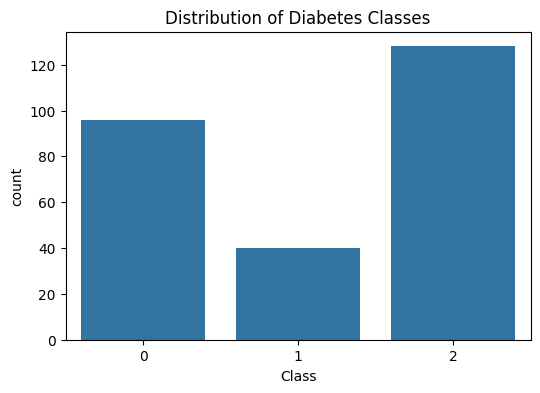

Class
2    128
0     96
1     40
Name: count, dtype: int64
Class
2    48.484848
0    36.363636
1    15.151515
Name: proportion, dtype: float64


In [12]:
# Class Distribution 
plt.figure(figsize=(6,4))

sns.countplot(
    data=df_eda,
    x="Class"
)

plt.title("Distribution of Diabetes Classes")

plt.show()

print(df_eda["Class"].value_counts())
print(df_eda["Class"].value_counts(normalize=True)*100)

The dataset contains 264 observations distributed across three diabetes categories:

- Diabetic (Class 2): 128 patients (48.48%)
- Non-Diabetic (Class 0): 96 patients (36.36%)
- Prediabetic (Class 1): 40 patients (15.15%)

The diabetic group represents nearly half of the dataset, reflecting the hospital-based nature of data collection. The prediabetic class is underrepresented, indicating a moderate class imbalance that should be considered during model evaluation.

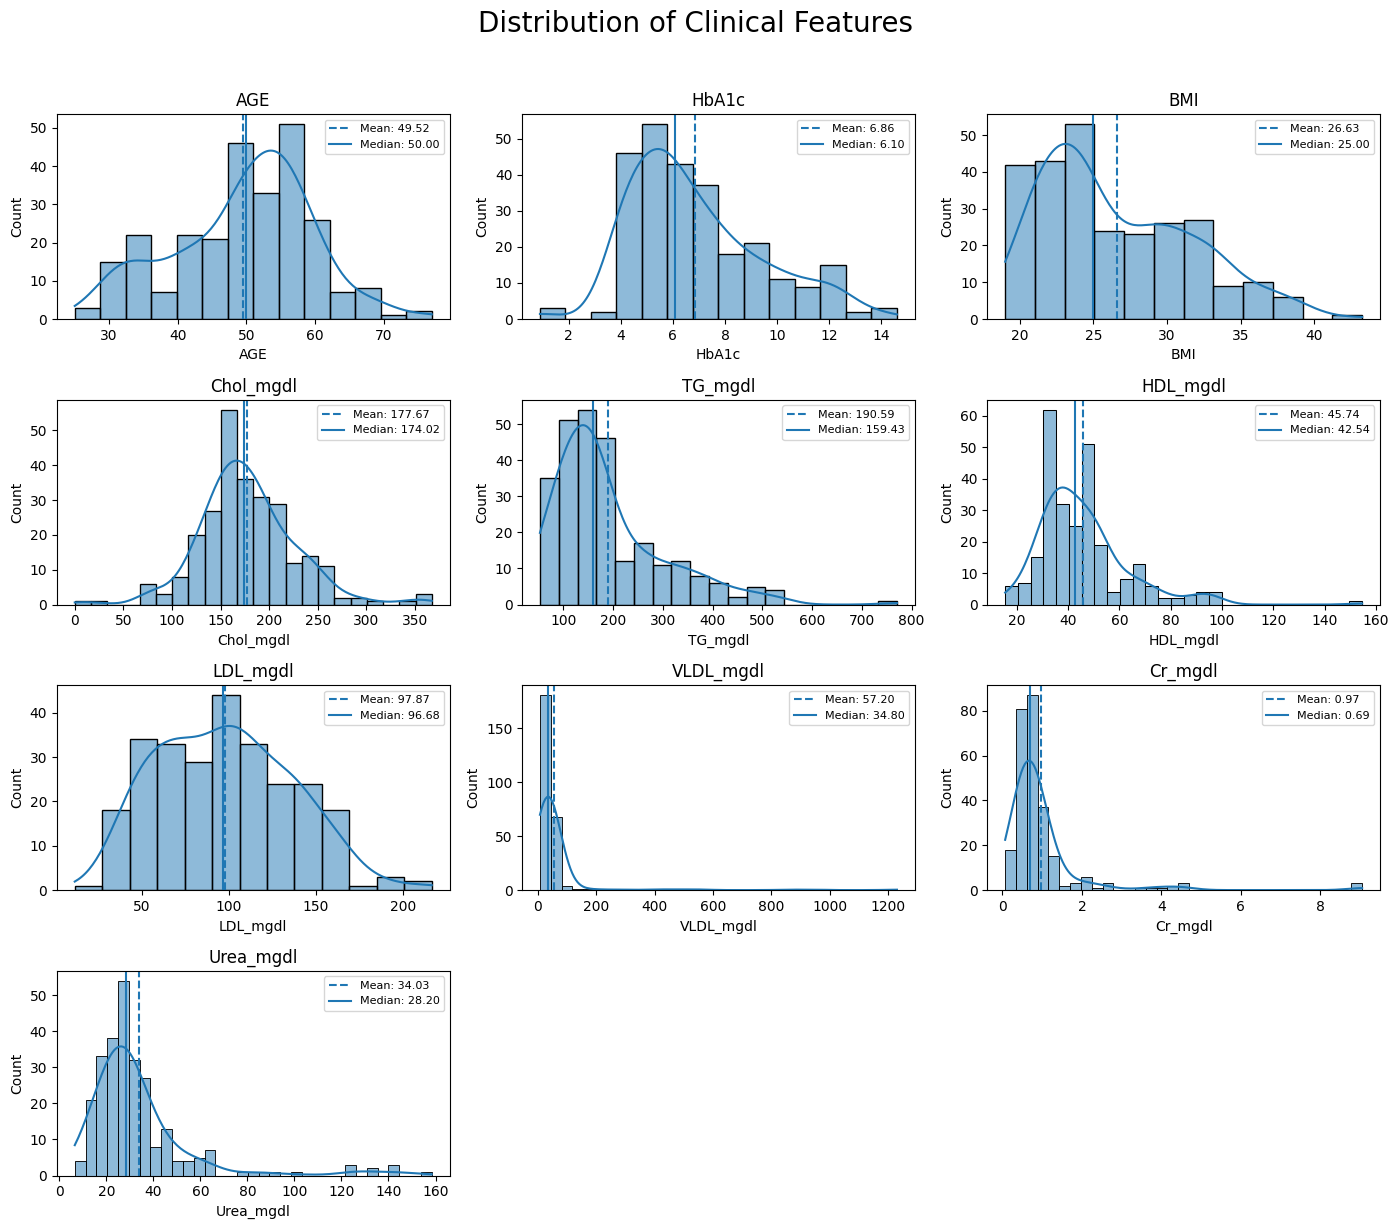

In [13]:
# HISTOGRAM WITH MEAN & MEDIAN

features = [
    "AGE",
    "HbA1c",
    "BMI",
    "Chol_mgdl",
    "TG_mgdl",
    "HDL_mgdl",
    "LDL_mgdl",
    "VLDL_mgdl",
    "Cr_mgdl",
    "Urea_mgdl"
]

fig, axes = plt.subplots(
    nrows=4,
    ncols=3,
    figsize=(14, 12)
)

axes = axes.flatten()

for i, col in enumerate(features):

    sns.histplot(
        df_eda[col],
        kde=True,
        ax=axes[i]
    )

    mean_val = df_eda[col].mean()
    median_val = df_eda[col].median()

    axes[i].axvline(
        mean_val,
        linestyle="--",
        label=f"Mean: {mean_val:.2f}"
    )

    axes[i].axvline(
        median_val,
        linestyle="-",
        label=f"Median: {median_val:.2f}"
    )

    axes[i].set_title(col)
    axes[i].legend(fontsize=8)

for j in range(len(features), len(axes)):
    fig.delaxes(axes[j])

plt.suptitle(
    "Distribution of Clinical Features",
    fontsize=20,
    y=1.02
)

plt.tight_layout()
plt.show()

In [14]:
# SKEWNESS CHECK

skew_df = pd.DataFrame({
    "Feature": features,
    "Skewness": [df_eda[col].skew() for col in features]
})

skew_df.sort_values(
    by="Skewness",
    ascending=False
)

,Feature,Skewness
7,VLDL_mgdl,7.004246
8,Cr_mgdl,5.009236
9,Urea_mgdl,2.968851
5,HDL_mgdl,1.737095
4,TG_mgdl,1.532176
1,HbA1c,0.741002
2,BMI,0.688048
3,Chol_mgdl,0.502825
6,LDL_mgdl,0.321014
0,AGE,-0.280394


### Insight

* AGE

    The age distribution is approximately symmetric with a mean age of 49.5 years, indicating that the dataset mainly consists of middle-aged adults.

* HbA1c
  
    HbA1c exhibits a moderate right-skewed distribution, suggesting the presence of patients with poor glycemic control.

* BMI

    BMI shows a moderate positive skew, indicating that overweight and obese individuals are common in the dataset.

* TG dan VLDL

    Triglycerides and VLDL display substantial positive skewness, reflecting severe dyslipidemia among some diabetic patients.

* Urea dan Creatinine

    Urea and Creatinine demonstrate strong positive skewness due to a subset of patients with impaired kidney function, a common complication of diabetes.

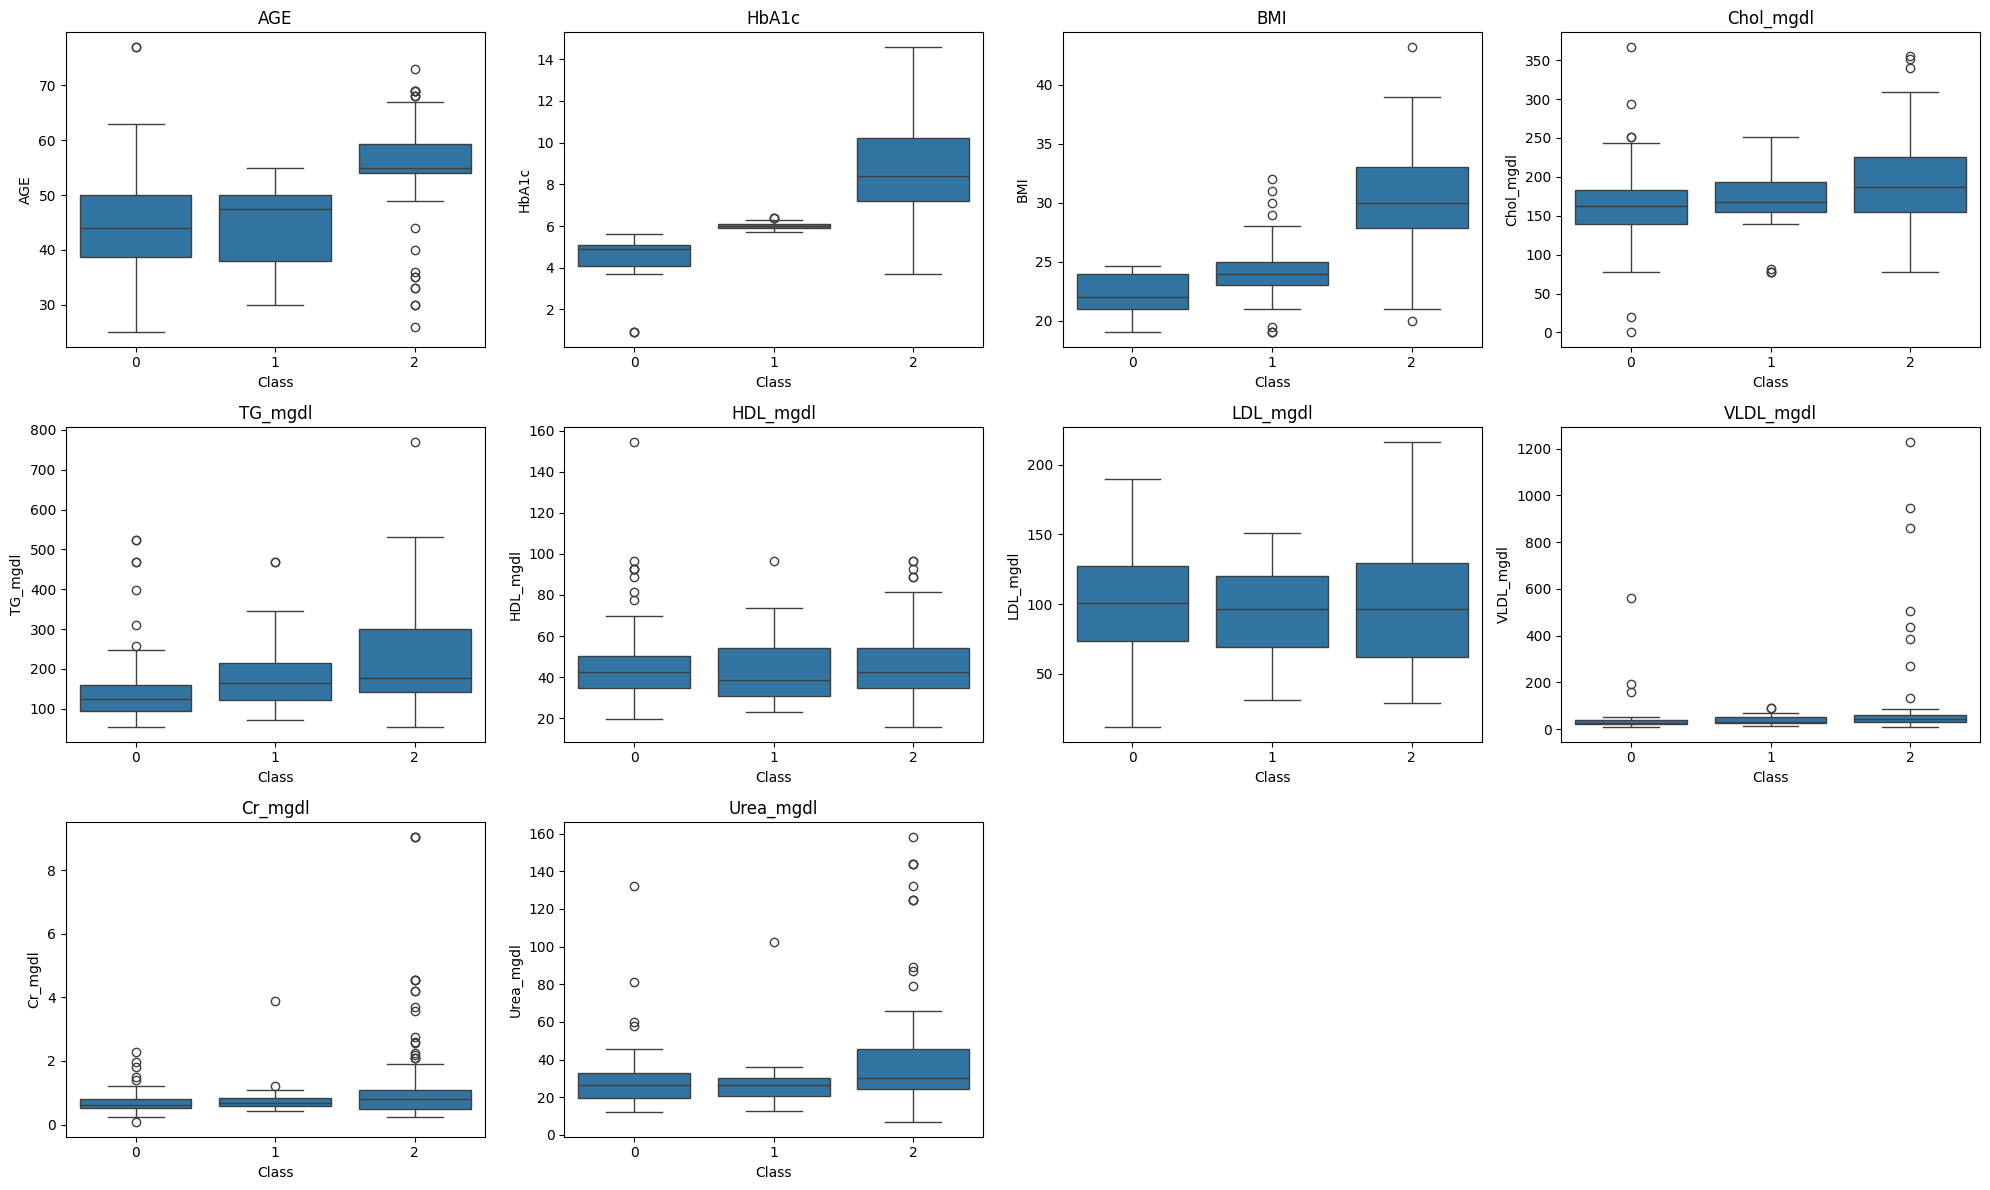

In [15]:
import math

# Boxplot per Class
n_features = len(features)
n_cols = 4
n_rows = math.ceil(n_features / n_cols)

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(5 * n_cols, 4 * n_rows)
)

axes = axes.flatten()

for i, feature in enumerate(features):

    sns.boxplot(
        data=df_eda,
        x="Class",
        y=feature,
        ax=axes[i]
    )
    
    axes[i].set_title(feature)
    axes[i].set_xlabel("Class")
    axes[i].set_ylabel(feature)

for j in range(len(features), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

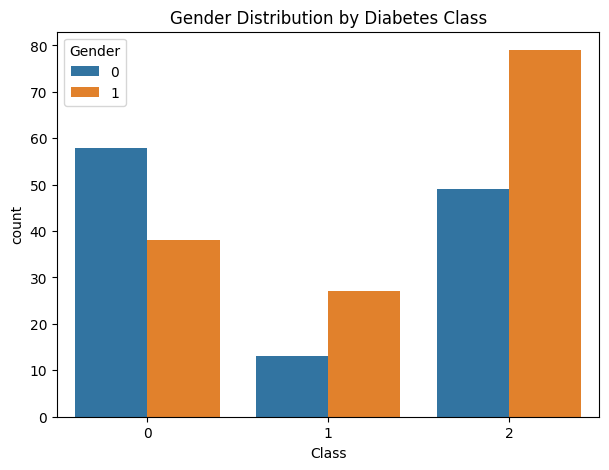

In [16]:
pd.crosstab(
    df_eda["Gender"],
    df_eda["Class"]
)

plt.figure(figsize=(7,5))

sns.countplot(
    data=df_eda,
    x="Class",
    hue="Gender"
)

plt.title("Gender Distribution by Diabetes Class")

plt.show()

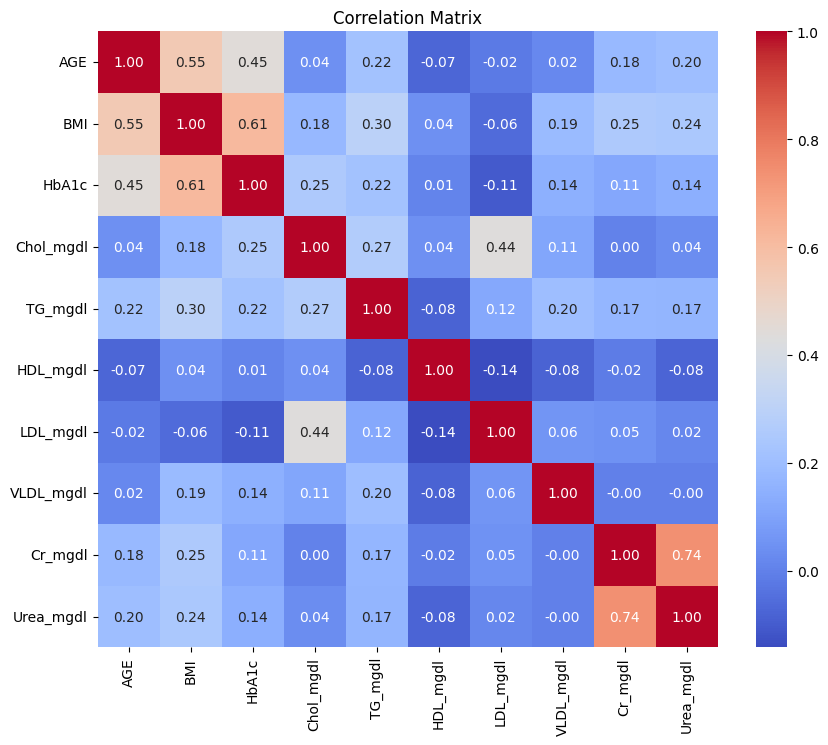

In [17]:
features = [
    "AGE",
    "BMI",
    "HbA1c",
    "Chol_mgdl",
    "TG_mgdl",
    "HDL_mgdl",
    "LDL_mgdl",
    "VLDL_mgdl",
    "Cr_mgdl",
    "Urea_mgdl"
]

corr = df_eda[features].corr()

plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.show()

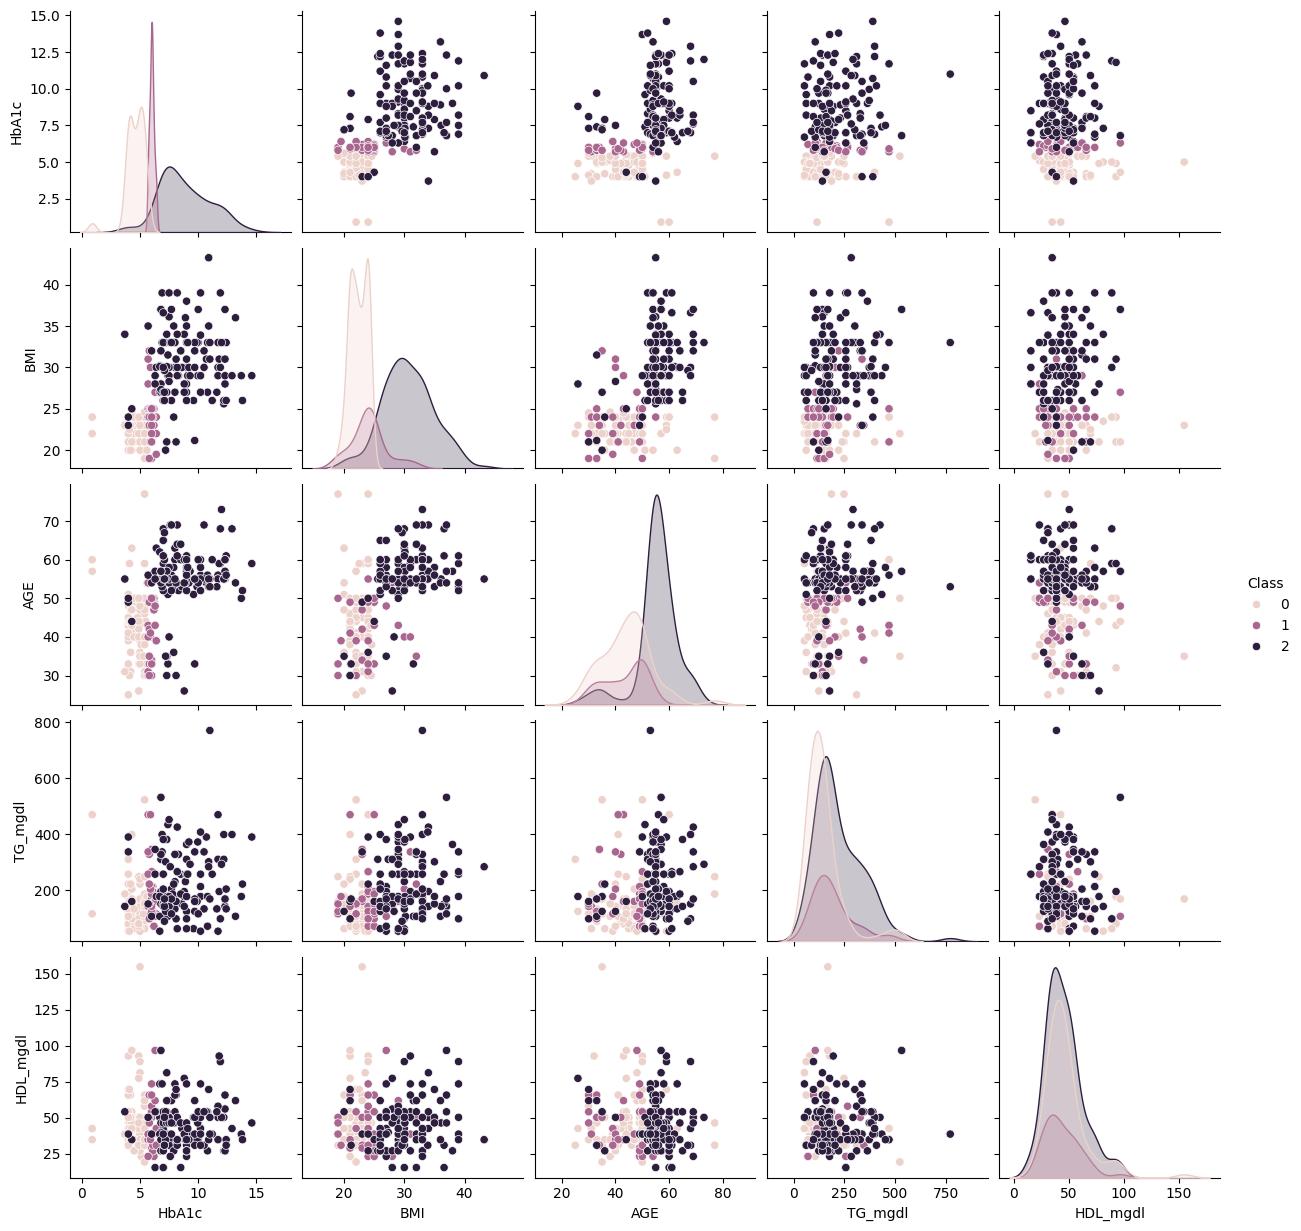

In [18]:
#Pairplot
pair_cols = [
    "HbA1c",
    "BMI",
    "AGE",
    "TG_mgdl",
    "HDL_mgdl",
    "Class"
]

sns.pairplot(
    df_eda[pair_cols],
    hue="Class"
)

plt.show()

Pairplot analysis reveals that HbA1c, BMI, and Age show the clearest separation among diabetes classes. Patients in Class 2 generally have higher HbA1c levels, higher BMI, and are older compared to Classes 0 and 1. Triglyceride levels exhibit substantial variability and several extreme outliers, while HDL demonstrates limited discriminative power due to overlapping distributions across classes. These findings suggest that HbA1c, BMI, and Age are likely among the most informative predictors for diabetes classification.

# 7. Statistical Testing

## 7.1. Shapiro-Wilk

In [19]:
# Shapiro-Wilk Normality Test

from scipy.stats import shapiro

results = []
print("Shapiro-Wilk :")

for col in features:
    stat, p = shapiro(df_eda[col])

    conclusion = (
        "Normal"
        if p > 0.05
        else "Abnormal"
    )

    results.append([
        col,
        stat,
        p,
        conclusion
    ])

shapiro_df = pd.DataFrame(
    results,
    columns=[
        "Feature",
        "Statistic",
        "p-value",
        "Conclusion"
    ]
)
shapiro_df = shapiro_df.sort_values(
    by="p-value"
)

shapiro_df

Shapiro-Wilk :


,Feature,Statistic,p-value,Conclusion
7,VLDL_mgdl,0.273467,6.703582e-31,Abnormal
8,Cr_mgdl,0.465727,2.103864e-27,Abnormal
9,Urea_mgdl,0.674640,3.150244e-22,Abnormal
4,TG_mgdl,0.864420,1.695960e-14,Abnormal
5,HDL_mgdl,0.877413,1.010424e-13,Abnormal
1,BMI,0.933669,1.662895e-09,Abnormal
2,HbA1c,0.936709,3.214108e-09,Abnormal
3,Chol_mgdl,0.962659,2.388767e-06,Abnormal
0,AGE,0.970143,2.533342e-05,Abnormal
6,LDL_mgdl,0.981283,1.522741e-03,Abnormal


## 7.2. Levene Test

For homogeneity of variance

In [20]:
# Levene Homogeneity Test

from scipy.stats import levene

print("Levene Test :")

results = []

for col in features:

    g0 = df_eda[df_eda["Class"] == 0][col]
    g1 = df_eda[df_eda["Class"] == 1][col]
    g2 = df_eda[df_eda["Class"] == 2][col]

    stat, p = levene(g0, g1, g2)

    conclusion = (
        "Homogeneous"
        if p > 0.05
        else "Not Homogeneous"
    )

    results.append([col, stat, p, conclusion])
    
    levene_df = pd.DataFrame(
        results,
        columns=[
            "Feature",
            "Statistic",
            "p-value",
            "Conclusion"
        ] 
    )

levene_df = levene_df.sort_values(by="p-value")
levene_df

Levene Test :


,Feature,Statistic,p-value,Conclusion
2,HbA1c,53.810532,2.709423e-20,Not Homogeneous
1,BMI,26.619070,3.015091e-11,Not Homogeneous
8,Cr_mgdl,7.395803,7.512074e-04,Not Homogeneous
9,Urea_mgdl,7.269722,8.464538e-04,Not Homogeneous
0,AGE,4.403601,1.315526e-02,Not Homogeneous
4,TG_mgdl,4.169824,1.649676e-02,Not Homogeneous
3,Chol_mgdl,2.761780,6.502637e-02,Homogeneous
7,VLDL_mgdl,2.685281,7.008637e-02,Homogeneous
6,LDL_mgdl,1.694597,1.856877e-01,Homogeneous
5,HDL_mgdl,0.129530,8.785643e-01,Homogeneous


In [21]:
# Assumption Summary
summary_df = (
    shapiro_df[["Feature", "Conclusion"]]
    .rename(columns={"Conclusion": "Normality"})
    .merge(
        levene_df[["Feature", "Conclusion"]],
        on="Feature"
    )
    .rename(columns={"Conclusion": "Homogenity"})
)

summary_df["Recommended Test"] = summary_df.apply(
    lambda row: (
        "ANOVA"
        if (
            row["Normality"] == "Normal"
            and row["Homogeneity"] == "Homogeneous"
        )
        else "Kruskal-Wallis"
    ),
    axis=1
)

summary_df

,Feature,Normality,Homogenity,Recommended Test
0,VLDL_mgdl,Abnormal,Homogeneous,Kruskal-Wallis
1,Cr_mgdl,Abnormal,Not Homogeneous,Kruskal-Wallis
2,Urea_mgdl,Abnormal,Not Homogeneous,Kruskal-Wallis
3,TG_mgdl,Abnormal,Not Homogeneous,Kruskal-Wallis
4,HDL_mgdl,Abnormal,Homogeneous,Kruskal-Wallis
5,BMI,Abnormal,Not Homogeneous,Kruskal-Wallis
6,HbA1c,Abnormal,Not Homogeneous,Kruskal-Wallis
7,Chol_mgdl,Abnormal,Homogeneous,Kruskal-Wallis
8,AGE,Abnormal,Not Homogeneous,Kruskal-Wallis
9,LDL_mgdl,Abnormal,Homogeneous,Kruskal-Wallis


## 7.3. Chi-Square

In [22]:
from scipy.stats import chi2_contingency

ct = pd.crosstab(
    df_eda["Gender"],
    df_eda["Class"]
)

chi2, p, dof, expected = chi2_contingency(ct)

print(f"Chi-square Statistic : {chi2:.4f}")
print(f"P-value              : {p:.4f}")

if p < 0.05:
    print("Significant Association")
else:
    print("No Significant Association")

Chi-square Statistic : 14.0321
P-value              : 0.0009
Significant Association


Interpretation

The Chi-Square test revealed a statistically significant association between gender and diabetes class (χ² = 14.03, p < 0.001). This finding suggests that the distribution of diabetes categories differs between males and females, indicating that gender may play a role in diabetes prevalence within this population.

## 7.4 Kruskal-Wallis

In [23]:
# Kruskal-Wallis Test
from scipy.stats import kruskal

results = []

for col in features:

    g0 = df_eda[df_eda["Class"] == 0][col]
    g1 = df_eda[df_eda["Class"] == 1][col]
    g2 = df_eda[df_eda["Class"] == 2][col]

    stat, p = kruskal(g0, g1, g2)

    results.append([
        col,
        stat,
        p,
        "Significant" if p < 0.05 else "Not Significant"
    ])

kruskal_df = pd.DataFrame(
    results,
    columns=[
        "Feature",
        "Statistic",
        "p-value",
        "Conclusion"
    ]
)

kruskal_df.sort_values("p-value")

,Feature,Statistic,p-value,Conclusion
2,HbA1c,197.530986,1.278472e-43,Significant
1,BMI,168.048497,3.226506e-37,Significant
0,AGE,113.300377,2.495374e-25,Significant
4,TG_mgdl,39.016232,3.370798e-09,Significant
7,VLDL_mgdl,32.814934,7.487342e-08,Significant
3,Chol_mgdl,20.120238,4.275096e-05,Significant
9,Urea_mgdl,17.711114,1.425872e-04,Significant
8,Cr_mgdl,7.084135,2.895340e-02,Significant
6,LDL_mgdl,1.756789,4.154494e-01,Not Significant
5,HDL_mgdl,0.726994,6.952408e-01,Not Significant


- Clinical Interpretation
    - HbA1c

        HbA1c demonstrated the strongest statistical difference among diabetes classes (p < 0.001), confirming its importance as the primary biomarker for distinguishing diabetic status. This finding aligns with its clinical role as a long-term indicator of blood glucose control.

    - BMI

        BMI exhibited substantial differences across diabetes categories (p < 0.001), indicating that obesity is strongly associated with diabetes progression in this cohort.

    - AGE

        Age was significantly associated with diabetes severity (p < 0.001), suggesting that older individuals are more likely to belong to higher-risk diabetes categories.

- Lipid Profile
    - TG and VLDL

        Triglycerides and VLDL levels differed significantly among diabetes classes, reflecting metabolic dysregulation commonly observed in diabetic patients.

    - Cholesterol

        Total cholesterol also showed significant variation across groups, although the effect was weaker than that observed for HbA1c and BMI.

    - HDL and LDL

        HDL and LDL cholesterol did not demonstrate statistically significant differences among diabetes categories. These markers may therefore have limited discriminatory power for diabetes classification within this dataset.

- Kidney Biomarkers
    - Urea and Creatinine

        Both urea and creatinine levels differed significantly among diabetes classes, suggesting the presence of renal impairment in diabetic individuals. These findings are consistent with diabetes-related kidney complications.

## 7.5. Dunn's Post Hoc

In [24]:
import sys
!{sys.executable} -m pip install scikit-posthocs


[notice] A new release of pip available: 22.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [25]:
# Dunn Test
import scikit_posthocs as sp

sp.posthoc_dunn(
    df_eda,
    val_col="HbA1c",
    group_col="Class",
    p_adjust="bonferroni"
)


,0,1,2
0,1.000000e+00,2.818554e-06,3.336070e-44
1,2.818554e-06,1.000000e+00,2.523457e-07
2,3.336070e-44,2.523457e-07,1.000000e+00


Interpretation

Dunn's post hoc analysis revealed significant pairwise differences in HbA1c across all diabetes categories. Non-diabetic, prediabetic, and diabetic groups each exhibited distinct HbA1c distributions, confirming the strong discriminative ability of this biomarker.

Conclusion

HbA1c can be separated:

- Non-Diabetic ↔ Prediabetic
- Non-Diabetic ↔ Diabetic
- Prediabetic ↔ Diabetic

## 8. Feature Engineering

In [26]:
df_ml = df_eda.copy()
df_ml.shape

(264, 19)

In [27]:
drop_cols = [
    "Cr",
    "Urea",
    "Chol",
    "TG",
    "HDL",
    "LDL",
    "VLDL"
]

df_ml = df_ml.drop(columns=drop_cols)
df_ml.head()

,Gender,AGE,HbA1c,BMI,Class,Cr_mgdl,Urea_mgdl,Chol_mgdl,HDL_mgdl,LDL_mgdl,TG_mgdl,VLDL_mgdl
0,0,50,4.9,24.0,0,0.520362,28.2,162.414,92.808,54.138,79.713,19.335
1,1,26,4.9,23.0,0,0.701357,27.0,143.079,42.537,81.207,123.998,23.202
2,1,33,4.9,21.0,0,0.520362,42.6,189.483,30.936,77.340,88.570,15.468
3,0,45,4.0,21.0,0,0.271493,13.8,112.143,38.670,58.005,88.570,15.468
4,0,50,4.0,24.0,0,0.565611,12.0,139.212,34.803,81.207,115.141,23.202


In [28]:
# Missing Value Check
missing_df = pd.DataFrame({
    "Missing": df_ml.isnull().sum(),
    "Percent": round(df_ml.isnull().mean()*100,2)
})

print(missing_df)
print("\nDuplicate :", df_ml.duplicated().sum())

           Missing  Percent
Gender           0      0.0
AGE              0      0.0
HbA1c            0      0.0
BMI              0      0.0
Class            0      0.0
Cr_mgdl          0      0.0
Urea_mgdl        0      0.0
Chol_mgdl        0      0.0
HDL_mgdl         0      0.0
LDL_mgdl         0      0.0
TG_mgdl          0      0.0
VLDL_mgdl        0      0.0

Duplicate : 0


### Multicollinearity Check

In [29]:
# Variance Inflation Factor

from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

X_vif = df_ml.drop(columns=["Class"])

# Add Intercept
X_vif_const = add_constant(X_vif)

vif_df = pd.DataFrame()

vif_df["Feature"] = X_vif_const.columns


vif_df["VIF"] = [
    variance_inflation_factor(
        X_vif_const.values, 
        i
    )
    for i in range(X_vif_const.shape[1])
]

# Interpretation
def interpret_vif(vif):

    if vif < 5:
        return "Safe"
    
    elif vif < 10:
        return "Moderate Multicollinearity"
    
    else:
        return "High Multicollinearity"

vif_df["Interpretation"] = vif_df["VIF"].apply(interpret_vif)

# Sort from highest VIF
vif_df.sort_values(
    by="VIF",
    ascending=False
)

vif_df.reset_index(drop=True, inplace=True)

vif_df = vif_df[vif_df["Feature"] != "const"]

vif_df


,Feature,VIF,Interpretation
1,Gender,1.116033,Safe
2,AGE,1.564365,Safe
3,HbA1c,1.820597,Safe
4,BMI,2.106606,Safe
5,Cr_mgdl,2.306477,Safe
6,Urea_mgdl,2.258020,Safe
7,Chol_mgdl,1.502866,Safe
8,HDL_mgdl,1.104664,Safe
9,LDL_mgdl,1.384436,Safe
10,TG_mgdl,1.222273,Safe


Insight

Variance Inflation Factor (VIF) analysis indicated no evidence of problematic multicollinearity among the predictor variables. All clinical and demographic features exhibited VIF values below 5, suggesting that each variable contributes distinct information to the classification task. Therefore, no feature was removed based on multicollinearity considerations.

# 9. Feature and Target

In [30]:
X = df_ml.drop(columns=["Class"])
y = df_ml["Class"]

print("X Shape:", X.shape)
print("y Shape:", y.shape)

X Shape: (264, 11)
y Shape: (264,)


# 10. Train-Test Split

In [31]:
# Train Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Shape X_train:", X_train.shape)
print("Shape X_test:", X_test.shape)
print("Shape y_train:", y_train.shape)
print("Shape y_test:", y_test.shape)

Shape X_train: (211, 11)
Shape X_test: (53, 11)
Shape y_train: (211,)
Shape y_test: (53,)


*   Train Set: 211 sampel (80%)
*   Test Set: 53 sampel (20%)

# 11. Feature Scaling

In [32]:
# FEATURE SCALING
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [33]:
# Change the scale to DataFrame
X_train_scaled = pd.DataFrame(
    X_train_scaled,
    columns=X.columns,
    index=X_train.index
)

X_test_scaled = pd.DataFrame(
    X_test_scaled,
    columns=X.columns,
    index=X_test.index
)

# 12. Baseline Model Comparison

In [34]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix)
from sklearn.model_selection import (cross_validate, StratifiedKFold)
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

models = [
    ('LogisticRegression', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)),
    ('Decision Tree', DecisionTreeClassifier(class_weight='balanced', random_state=42)),
    ('Random Forest', RandomForestClassifier(class_weight='balanced', random_state=42)),
    ('KNN', KNeighborsClassifier()),
    ('XGBoost', XGBClassifier(random_state=42, eval_metric='mlogloss'))
]

# Stratified K-Fold
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Baseline Modell Comparison
results = []

for name, model in models:

    scores = cross_validate(
        model,
        X_train_scaled,
        y_train,
        cv=cv,
        scoring={
            'accuracy':'accuracy',
            'precision':'precision_weighted',
            'recall':'recall_weighted',
            'f1':'f1_weighted',
            'roc_auc': 'roc_auc_ovr_weighted'
        },
        n_jobs=-1

    )

    results.append([
        name,
        round(scores['test_accuracy'].mean() * 100, 2),
        round(scores['test_precision'].mean() * 100, 2),
        round(scores['test_recall'].mean() * 100, 2),
        round(scores['test_roc_auc'].mean() * 100, 2),
        round(scores['test_f1'].mean() * 100, 2)
    ])

    
model_results = pd.DataFrame(
    results,
    columns=[
        'Model',
        'Accuracy Mean',
        'Precision',
        'Recall',
        'ROC AUC',
        'F1 Score'
    ]
)

print('Model Comparison Rresults: \n')
model_results = model_results.sort_values(by='F1 Score', ascending=False)

print(model_results)

# Best Model Selection
best_model_name = model_results.iloc[0]['Model']
best_model = dict(models)[best_model_name]
print(f"\nBest Model: {best_model_name}")

Model Comparison Rresults: 

                Model  Accuracy Mean  Precision  Recall  ROC AUC  F1 Score
4             XGBoost          97.63      97.85   97.63    99.64     97.60
1       Decision Tree          96.69      97.14   96.69    97.29     96.67
2       Random Forest          96.69      96.99   96.69    99.39     96.67
0  LogisticRegression          85.30      88.14   85.30    96.42     85.99
3                 KNN          79.60      80.58   79.60    91.65     79.07

Best Model: XGBoost


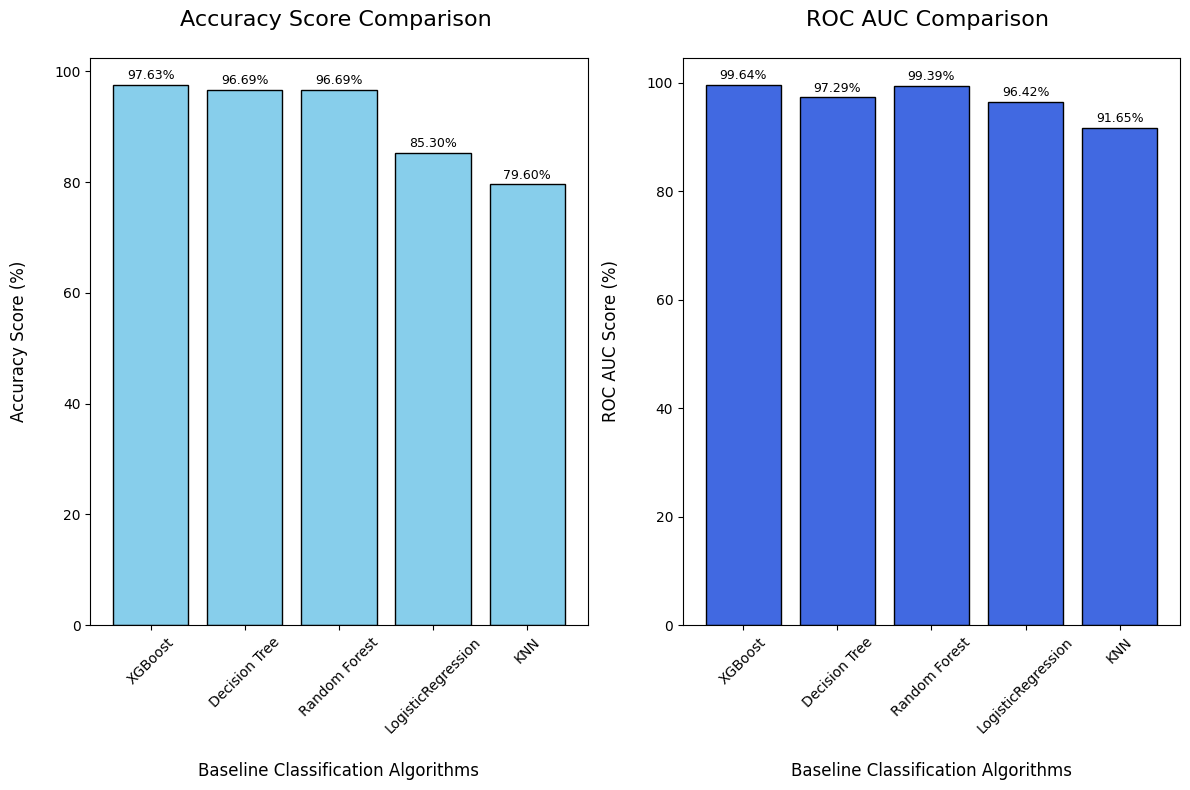

In [35]:
# Step 15.2.  Visualize Classification F1 Scores Accuracy Comparisons:
fig, axes = plt.subplots(1, 2, figsize=(12,8))

# Subplot 1 - Accuracy Comparison
bars1 = axes[0].bar(model_results['Model'], model_results['Accuracy Mean'],
                    color='skyblue', edgecolor='black')
axes[0].set_ylabel('Accuracy Score (%)\n', horizontalalignment="center",
                   fontstyle="normal", fontsize="large", fontfamily="sans-serif")
axes[0].set_xlabel('\nBaseline Classification Algorithms', horizontalalignment="center",
                   fontstyle="normal", fontsize="large", fontfamily="sans-serif")
axes[0].set_title('Accuracy Score Comparison \n', horizontalalignment="center",
                  fontstyle="normal", fontsize=16, fontfamily="sans-serif")
axes[0].tick_params(axis='x', rotation=45)

# persentase bar Accuracy
for bar in bars1:
    height = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2., height + 0.5,
                 f'{height:.2f}%', ha='center', va='bottom', fontsize=9)

# Subplot 2 - ROC AUC Comparison
bars2 = axes[1].bar(model_results['Model'], model_results['ROC AUC'],
                    color='royalblue', edgecolor='black')
axes[1].set_ylabel('ROC AUC Score (%)\n', horizontalalignment="center",
                   fontstyle="normal", fontsize="large", fontfamily="sans-serif")
axes[1].set_xlabel('\nBaseline Classification Algorithms', horizontalalignment="center",
                   fontstyle="normal", fontsize="large", fontfamily="sans-serif")
axes[1].set_title('ROC AUC Comparison \n', horizontalalignment="center",
                  fontstyle="normal", fontsize=16, fontfamily="sans-serif")
axes[1].tick_params(axis='x', rotation=45)

# persentase bar ROC AUC
for bar in bars2:
    height = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2., height + 0.5,
                 f'{height:.2f}%', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

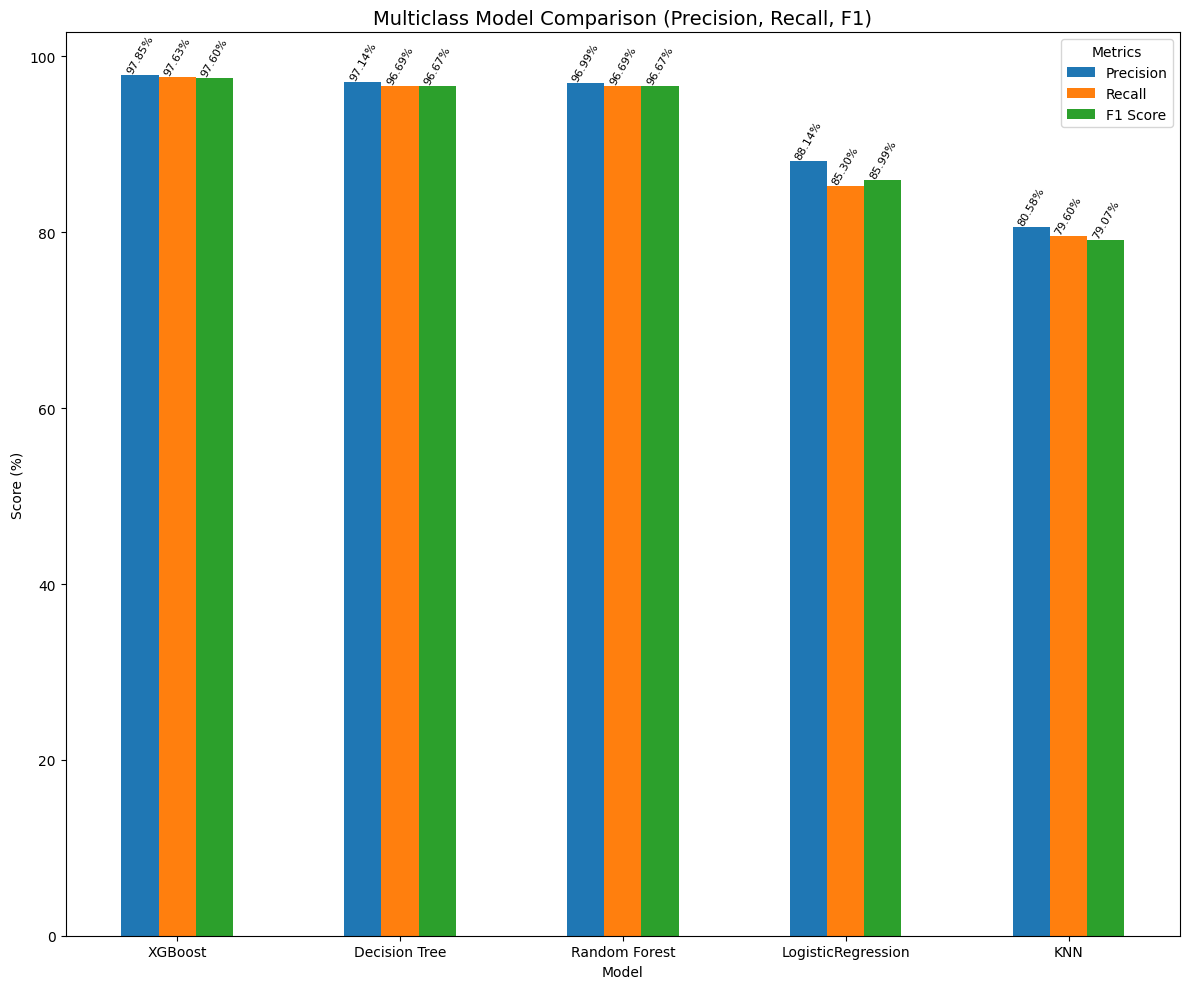

In [36]:
# Visualization
ax = model_results.set_index("Model")[["Precision", "Recall", "F1 Score"]].plot(
    kind="bar", figsize=(12, 10))

plt.title("Multiclass Model Comparison (Precision, Recall, F1)", fontsize=14)
plt.ylabel("Score (%)")
plt.xticks(rotation=0)
plt.legend(title="Metrics")

# Tambahkan label persentase di atas setiap bar
for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.2f%%',
        label_type='edge',
        fontsize=8,
        rotation=60
    )

plt.tight_layout()
plt.show()

# 13. Hyperparameter Tuning (Best Moedel)

In [37]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import roc_auc_score

# Base Model
xgb_base = XGBClassifier(random_state=42, eval_metric='mlogloss')

# Hyperparametere Search Space
param_grid = {
    "n_estimators" : [50, 100, 200, 300],
    "max_depth" : [3, 4, 5, 6, 8],
    "learning_rate" : [0.01, 0.05, 0.1, 0.2],
    "subsample" : [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree" : [0.7, 0.8, 0.9, 1.0],
    "min_child_weight" : [1, 3, 5]
}


# Random Search CV
random_search = RandomizedSearchCV(

    estimator=xgb_base,
    param_distributions=param_grid,
    n_iter=50,
    scoring='f1_weighted',
    cv=5,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train_scaled, y_train)

# Best Model
best_xgb = random_search.best_estimator_

print("Best Parameters")
print(random_search.best_params_)

print(
    f"Best CV F1 Score: "
    f"{random_search.best_score_*100:.2f}%"
)



Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best Parameters
{'subsample': 0.9, 'n_estimators': 50, 'min_child_weight': 3, 'max_depth': 6, 'learning_rate': 0.05, 'colsample_bytree': 0.8}
Best CV F1 Score: 97.13%


# 14. Final Evaluation on Test Set

In [38]:
# Evaluation on test set
print("\nXGBoost")

#Train Model
best_xgb = random_search.best_estimator_
best_xgb.fit(X_train_scaled, y_train)

# Prediction
y_pred_xgb = best_xgb.predict(X_test_scaled)
y_prob_xgb = best_xgb.predict_proba(X_test_scaled)

# Metrics
accuracy = accuracy_score(y_test, y_pred_xgb)
precision = precision_score(y_test, y_pred_xgb, average='weighted')
recall = recall_score(y_test, y_pred_xgb, average='weighted')
f1 = f1_score(y_test, y_pred_xgb, average='weighted')
roc_auc = roc_auc_score(y_test, y_prob_xgb, multi_class='ovr', average='macro')

# Summary Table
evaluation_df = pd.DataFrame({

    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC AUC"
    ],

    "Score (%)": [

        round(accuracy*100,2),
        round(precision*100,2),
        round(recall*100,2),
        round(f1*100,2),
        round(roc_auc*100,2)
    ]
})

print("Final Model Performance")
display(evaluation_df)

# Confusion Matrix
print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred_xgb))

# Classification Report
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_xgb))


XGBoost
Final Model Performance


,Metric,Score (%)
0,Accuracy,98.11
1,Precision,98.21
2,Recall,98.11
3,F1 Score,98.12
4,ROC AUC,99.91



Confusion Matrix
[[19  0  0]
 [ 0  8  0]
 [ 1  0 25]]

Classification Report:

              precision    recall  f1-score   support

           0       0.95      1.00      0.97        19
           1       1.00      1.00      1.00         8
           2       1.00      0.96      0.98        26

    accuracy                           0.98        53
   macro avg       0.98      0.99      0.98        53
weighted avg       0.98      0.98      0.98        53



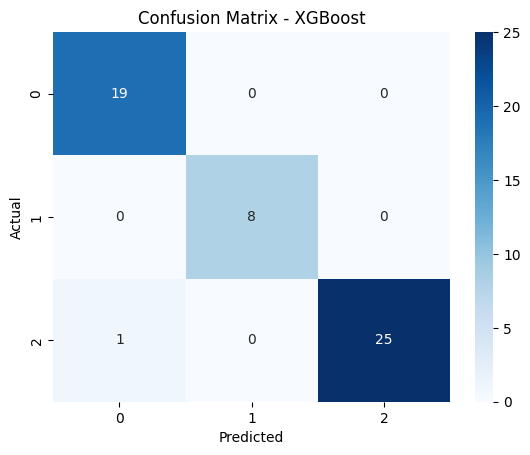

In [39]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_xgb)

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title(f'Confusion Matrix - {best_model_name}')

plt.show()

# 15. Overvitting Analysis

In [40]:
# Overfitting Check
train_pred = best_xgb.predict(X_train_scaled)

train_f1 = f1_score(y_train, train_pred, average='weighted')
test_f1 = f1_score(y_test, y_pred_xgb, average='weighted')

# GAP
gap = train_f1 - test_f1

print("Overfitting Analysis:\n")

print(f"Train F1 Score : {train_f1*100:.2f}%")
print(f"Test F1 Score : {test_f1*100:.2f}%")
print(f"Performance Gap : {gap*100:.2f}%")

# Interpretation
if gap < 0.03:
    interpretation = "Excellent Generalization"
elif gap < 0.05:
    interpretation = "Slight Overfitting"
elif gap <0.10:
    interpretation = "Moderate Overfitting"
else:
    interpretation = "Severe Overfitting"

print(f"\nInterpretation : {interpretation}")

Overfitting Analysis:

Train F1 Score : 99.05%
Test F1 Score : 98.12%
Performance Gap : 0.93%

Interpretation : Excellent Generalization


## ROC Curve per Class

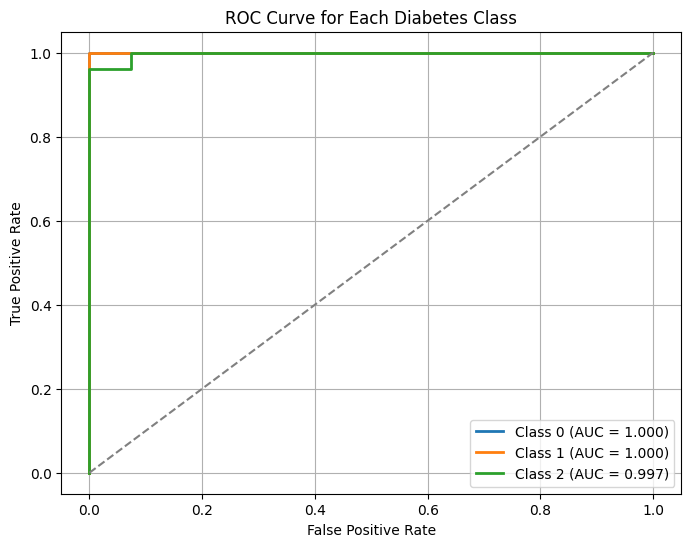

In [41]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

# Predict Probability
y_prob = best_xgb.predict_proba(X_test_scaled)

# Binarize Label
classes = [0, 1, 2]
y_test_bin = label_binarize(y_test, classes=classes)

# ROC Curve
plt.figure(figsize=(8,6))

for i in range(len(classes)):

    fpr, tpr, _ = roc_curve(
        y_test_bin[:, i],
        y_prob[:, i]
    )
    
    roc_auc = auc(fpr, tpr)

    plt.plot( fpr, tpr, lw=2, label=f"Class {i} (AUC = {roc_auc:.3f})")

# Random Guess Line
plt.plot([0,1], [0,1], linestyle="--", color="gray")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve for Each Diabetes Class")

plt.legend()
plt.grid(True)
plt.show()

### Cek Overfitting pakai plot Learning Curve

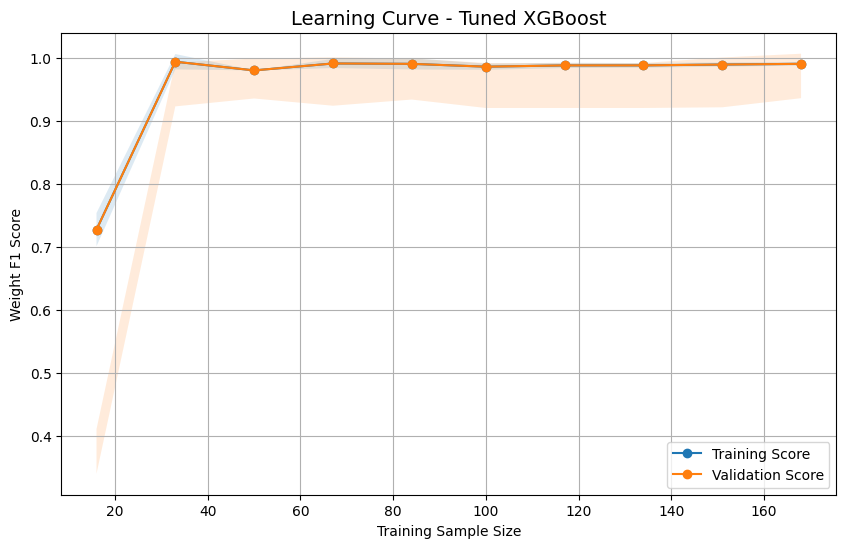

In [42]:
from sklearn.model_selection import learning_curve

# Count Learning Curve
train_sizes, train_scores, validation_scores = learning_curve(
    estimator=best_xgb,
    X=X_train_scaled,
    y=y_train,
    cv=5,
    scoring='f1_weighted',
    n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 10)
)

# Mean Score
train_mean = np.mean(train_scores, axis=1)
validation_mean = np.mean(validation_scores, axis=1)

# Standard Deviation
train_std = np.std(train_scores, axis=1)
validation_std = np.std(validation_scores, axis=1)

# Plot
plt.figure(figsize=(10, 6))

plt.plot(
    train_sizes,
    train_mean,
    marker = 'o',
    label = 'Training Score'
)

plt.plot(
    train_sizes, 
    train_mean, 
    marker = 'o', 
    label = 'Validation Score'
)

# Confidence Interval
plt.fill_between(
    train_sizes,
    train_mean - train_std,
    train_mean + train_std,
    alpha = 0.15
)

plt.fill_between(
    train_sizes,
    validation_mean - validation_std,
    validation_mean + validation_std,
    alpha = 0.15
)

plt.title('Learning Curve - Tuned XGBoost', fontsize=14)
plt.xlabel('Training Sample Size')
plt.ylabel('Weight F1 Score')
plt.legend()
plt.grid(True)
plt.show()


**Insight** :

The learning curve demonstrates excellent model generalization. Both training and validation weighted F1 scores converge at approximately 99%, with a minimal performance gap. The validation curve stabilizes as the training sample size increases, indicating that the model effectively captures the underlying clinical patterns without substantial overfitting or underfitting. These findings suggest that the selected biomarkers provide strong predictive signals for diabetes classification.

# 16. Model Interpretation

## Feature Importance

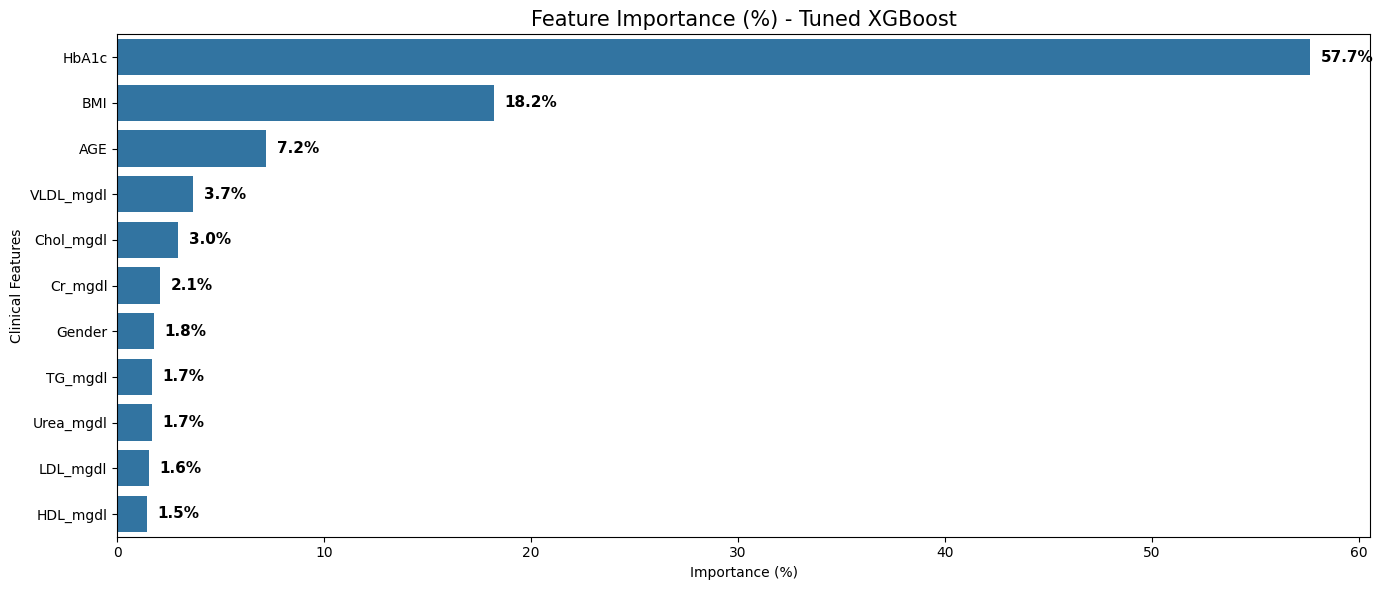

In [43]:
# Feature Importance Visualization
feature_importance = pd.DataFrame({

    "Feature": X.columns,
    "Importance": best_xgb.feature_importances_
})

# Sort Descending
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

# Convert to Persentage
feature_importance["Importance (%)"] = (
    feature_importance["Importance"] * 100
)

# Plot
plt.figure(figsize=(14,6))

ax = sns.barplot(
    data=feature_importance,
    x="Importance (%)",
    y="Feature"
)

# Add Percentage Labels
for i, value in enumerate(feature_importance["Importance (%)"]):

    ax.text(
        value + 0.5,
        i,
        f"{value:.1f}%",
        va="center",
        fontsize=11,
        fontweight="bold"
    )

plt.title(
    "Feature Importance (%) - Tuned XGBoost",
    fontsize=15
)

plt.xlabel("Importance (%)")
plt.ylabel("Clinical Features")
plt.tight_layout()
plt.show()

In [44]:
# Percentage Contribution
feature_importance["Contribution (%)"] = (
    feature_importance["Importance"] / 
    feature_importance["Importance"].sum()
) * 100

feature_importance["Contribution (%)"] = (
    feature_importance["Contribution (%)"]
    .round(2)
)

feature_importance

,Feature,Importance,Importance (%),Contribution (%)
2,HbA1c,0.576680,57.667984,57.669998
3,BMI,0.182324,18.232439,18.230000
1,AGE,0.072065,7.206450,7.210000
10,VLDL_mgdl,0.036791,3.679065,3.680000
6,Chol_mgdl,0.029537,2.953668,2.950000
4,Cr_mgdl,0.020684,2.068389,2.070000
0,Gender,0.017904,1.790434,1.790000
9,TG_mgdl,0.016992,1.699241,1.700000
5,Urea_mgdl,0.016977,1.697682,1.700000
8,LDL_mgdl,0.015511,1.551126,1.550000


In [45]:
# Top 5 Feature
top5_features = feature_importance.head(5)
top5_features

,Feature,Importance,Importance (%),Contribution (%)
2,HbA1c,0.576680,57.667984,57.669998
3,BMI,0.182324,18.232439,18.230000
1,AGE,0.072065,7.206450,7.210000
10,VLDL_mgdl,0.036791,3.679065,3.680000
6,Chol_mgdl,0.029537,2.953668,2.950000


**Insight by Feature Importance**

Overall, the feature importance analysis aligns well with the statistical findings obtained from the Kruskal–Wallis test, where HbA1c, BMI, and Age were identified as highly significant variables. This consistency increases confidence in the reliability and interpretability of the proposed XGBoost model.

## SHAP Analysis

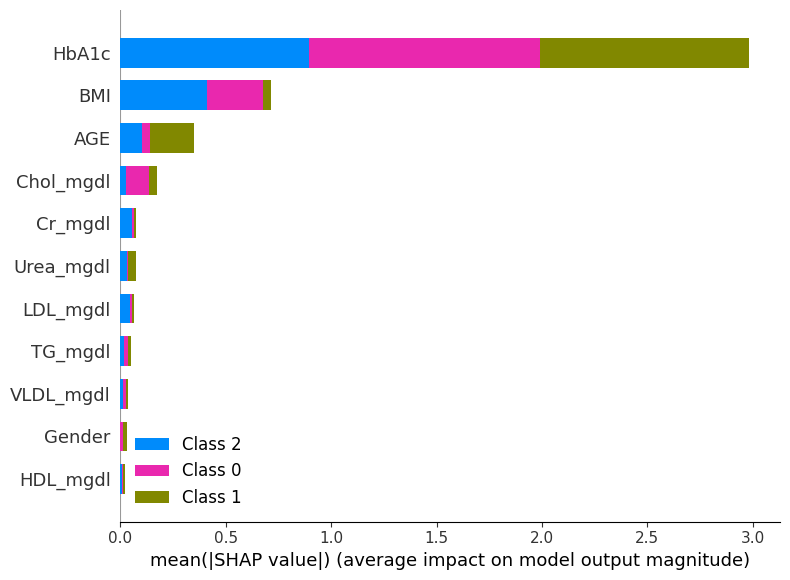

In [46]:
import shap

explainer = shap.TreeExplainer(best_xgb)
shap_values = explainer.shap_values(X_train_scaled)

shap.summary_plot(

    shap_values,
    X_train_scaled,
    feature_names=X.columns,
    plot_type="bar"
)

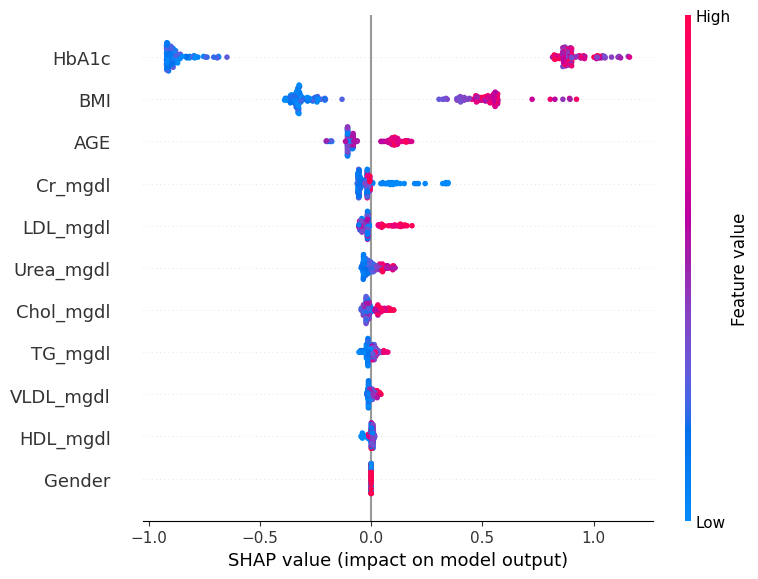

In [47]:
import shap

class_idx = 2

shap.summary_plot(
    shap_values[:, :, class_idx],
    X_train_scaled,
    feature_names=X.columns
)

**Insight by SHAP**

The SHAP findings are consistent with both the statistical analyses and existing medical knowledge. HbA1c, BMI, and AGE consistently emerged as the three most influential predictors across multiple analytical approaches, indicating that the model captures clinically meaningful patterns rather than relying on spurious correlations.

# 17. Final Conclusion


The tuned XGBoost model achieved an Accuracy of 98.11%, an F1-score of 98.12%, and a multiclass ROC-AUC of 99.91%, outperforming all baseline models. The learning curve indicates good generalization without signs of overfitting. Statistical analysis and SHAP interpretation consistently identified HbA1c, BMI, and AGE as the most influential predictors, demonstrating that the model captures clinically meaningful relationships for multiclass diabetes classification.

# 18. Business / Clinical Recommendation

- Patients with elevated HbA1c should receive priority screening due to its dominant predictive contribution.

- Individuals with high BMI and older age should be monitored more closely for diabetes progression.

- Lipid profile and kidney biomarkers provide additional clinical value but have lower predictive importance than glycemic indicators.

- The proposed model could support early diabetes risk stratification in clinical decision support systems, although external validation on larger and more diverse populations is recommended before real-world deployment.

In [48]:
# 1. Check library version
import sklearn
import numpy
import pandas
import joblib
import seaborn
import streamlit
import matplotlib

print("VERSI LIBRARY SAAT TRAINING:")
print("scikit-learn:", sklearn.__version__)
print("numpy:", numpy.__version__)
print("pandas:", pandas.__version__)
print("joblib:", joblib.__version__)
print("seaborn:", seaborn.__version__)
print("streamlit:", seaborn.__version__)
print("SHAP version:", shap.__version__)
print("matplotlib:", matplotlib.__version__)
print("-"*50)


VERSI LIBRARY SAAT TRAINING:
scikit-learn: 1.8.0
numpy: 2.4.1
pandas: 2.3.3
joblib: 1.5.3
seaborn: 0.13.2
streamlit: 0.13.2
SHAP version: 0.51.0
matplotlib: 3.10.8
--------------------------------------------------


In [49]:
# Save Model & Scaler
import joblib

joblib.dump(best_xgb, "/Users/AtikahDR/Documents/Data Science Project/Multiclass Diabetes/tuned_xgboost.pkl")
joblib.dump(scaler, "/Users/AtikahDR/Documents/Data Science Project/Multiclass Diabetes/scaler.pkl")

feature_columns = list(X.columns)
joblib.dump(feature_columns, "/Users/AtikahDR/Documents/Data Science Project/Multiclass Diabetes/feature_columns.pkl")

print("Model dan scaler berhasil disimpan!")

Model dan scaler berhasil disimpan!
